# This code is for IQA

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import torch
import os
import torchvision.transforms as T
import torchvision.datasets as datasets
from torchvision.models import inception_v3
from torchvision.utils import save_image
from PIL import Image
#import metrics
from skimage.metrics import structural_similarity as SSIM
from skimage.metrics import peak_signal_noise_ratio as PSNR
from sklearn.metrics import mean_absolute_error as MAE
from torchmetrics.image.fid import FrechetInceptionDistance

# ## 1. Import Required Libraries

In [39]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Import LPIPS if available
try:
    import lpips
    LPIPS_AVAILABLE = True
    print("✓ LPIPS library available")
except ImportError:
    LPIPS_AVAILABLE = False
    print("⚠️  LPIPS not available. Install with: pip install lpips")


✓ LPIPS library available


 ## 2. Define Helper Functions

In [40]:
def load_nifti_slice(path, slice_idx=None):
    """Load and extract a 2D slice from a NIfTI file"""
    img = nib.load(path)
    data = img.get_fdata()
    print(f"{os.path.basename(path)}: {data.shape}")
    
    # Use middle slice if no specific slice index provided
    if slice_idx is None:
        slice_idx = data.shape[2] // 2
    
    slice_2d = data[:, :, slice_idx]
    slice_2d = np.rot90(slice_2d)  # Rotate for proper orientation
    
    # Normalize to [0, 1]
    if np.max(slice_2d) > 0:
        return slice_2d / np.max(slice_2d)
    else:
        return slice_2d

def extract_patient_id(filename):
    """Extract patient ID from filename"""
    basename = os.path.basename(filename)
    if 'sub-MS' in basename:
        patient_part = basename.split('sub-MS')[1].split('_')[0]
        if '3T' in patient_part:
            return patient_part.replace('3T', '')
        elif '7T' in patient_part:
            return patient_part.replace('7T', '')
    return basename.split('_')[0]

 ## 3. Metric Calculation Functions


In [41]:

def compute_mae(img1, img2):
    """Compute Mean Absolute Error"""
    return np.mean(np.abs(img1 - img2))

def compute_psnr(img1, img2):
    """Compute Peak Signal-to-Noise Ratio"""
    return psnr(img1, img2, data_range=1.0)

def compute_ssim(img1, img2):
    """Compute Structural Similarity Index"""
    return ssim(img1, img2, data_range=1.0)

def compute_lpips(img1, img2, lpips_model=None):
    """Compute LPIPS (Learned Perceptual Image Patch Similarity)"""
    if not LPIPS_AVAILABLE or lpips_model is None:
        return np.nan
    
    import torch
    
    # Convert to 3-channel by repeating grayscale
    img1_3ch = np.stack([img1, img1, img1], axis=2)
    img2_3ch = np.stack([img2, img2, img2], axis=2)
    
    # Convert to torch tensors (C, H, W format)
    img1_tensor = torch.tensor(img1_3ch).permute(2, 0, 1).unsqueeze(0).float()
    img2_tensor = torch.tensor(img2_3ch).permute(2, 0, 1).unsqueeze(0).float()
    
    # Normalize to [-1, 1] for LPIPS
    img1_tensor = 2 * img1_tensor - 1
    img2_tensor = 2 * img2_tensor - 1
    
    with torch.no_grad():
        lpips_value = lpips_model(img1_tensor, img2_tensor)
    
    return lpips_value.item()


# ## 4. Configuration


In [42]:

# Set your data directory path
DATA_DIR = "/home/nbelloula/GAI/Synthetic7TMRI4/data/original"
OUTPUT_CSV = "mri_metrics_results.csv"
SLICE_IDX = None  # None for middle slice, or specify a number

print(f" Data directory: {DATA_DIR}")
print(f" Output CSV: {OUTPUT_CSV}")
print(f" Slice index: {'Middle slice' if SLICE_IDX is None else SLICE_IDX}")


 Data directory: /home/nbelloula/GAI/Synthetic7TMRI4/data/original
 Output CSV: mri_metrics_results.csv
 Slice index: Middle slice



# ## 5. Initialize LPIPS Model


In [43]:
lpips_model = None
if LPIPS_AVAILABLE:
    try:
        lpips_model = lpips.LPIPS(net='alex')
        print("✓ LPIPS model loaded successfully")
    except Exception as e:
        print(f"❌ Failed to load LPIPS model: {e}")
        LPIPS_AVAILABLE = False

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/nbelloula/miniconda3/envs/nahla/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
✓ LPIPS model loaded successfully


# ## 6. Find and Process Patients

In [44]:
# Define paths
path_3T = os.path.join(DATA_DIR, "3T")
path_7T_real = os.path.join(DATA_DIR, "7T")
path_7T_synth_p = os.path.join(DATA_DIR, "7TSynthPretrained")

print(f"🔍 Searching in:")
print(f"  3T: {path_3T}")
print(f"  7T Real: {path_7T_real}")
print(f"  7T Synthetic: {path_7T_synth_p}")

# Get all 7T files
files_7T_synth_p = glob.glob(os.path.join(path_7T_synth_p, "*.nii.gz"))
print(f"\n📊 Found {len(files_3T)} synthesized 7T files (pretrained model)")

# Display found files
for i, file in enumerate(files_7T_synth_p[:5]):  # Show first 5
    print(f"  {i+1}. {os.path.basename(file)}")
if len(files_7T_synth_p) > 5:
    print(f"  ... and {len(files_7T_synth_p) - 5} more")


🔍 Searching in:
  3T: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/3T
  7T Real: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/7T
  7T Synthetic: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/7TSynthPretrained

📊 Found 18 synthesized 7T files (pretrained model)
  1. sub-MS3T011_T1w_MNI152_ANTs_pred.nii.gz
  2. sub-MS3T002_T1w_MNI152_ANTs_pred.nii.gz
  3. sub-MS3T016_T1w_MNI152_ANTs_pred.nii.gz
  4. sub-MS3T010_T1w_MNI152_ANTs_pred.nii.gz
  5. sub-MS3T012_T1w_MNI152_ANTs_pred.nii.gz
  ... and 13 more


# ## 7. Process Each Patient for the pretrained model

In [45]:
results_pretrained = []
# Get all 3T files
files_3T = glob.glob(os.path.join(path_3T, "*.nii.gz"))
print(f"\n📊 Found {len(path_3T)} original 3T ")

for i, file_3T in enumerate(files_3T):
    patient_id = extract_patient_id(file_3T)
    print(f"\n{'='*50}")
    print(f"🏥 Processing Patient {patient_id} ({i+1}/{len(files_3T)})")
    print(f"{'='*50}")
    
    # Find corresponding 7T files
    file_7T_real = None
    file_7T_synth_p = None  

    possible_7T_real = glob.glob(os.path.join(path_7T_real, f"*{patient_id}*"))
    if possible_7T_real:
        file_7T_real = possible_7T_real[0]
    
    possible_7T_synth_p = glob.glob(os.path.join(path_7T_synth_p, f"*{patient_id}*"))  
    if possible_7T_synth_p:
        file_7T_synth_p = possible_7T_synth_p[0]
    
    if not all([file_7T_real, file_7T_synth_p]):
        print(f"⚠️  Missing files for patient {patient_id}")
        print(f"   3T: {'✓' if file_3T else '❌'}")
        print(f"   7T Real: {'✓' if file_7T_real else '❌'}")
        print(f"   7T Synth: {'✓' if file_7T_synth_p else '❌'}")  
        continue
    
    try:
        # Load slices
        print("📥 Loading slices...")
        img_3T = load_nifti_slice(file_3T, SLICE_IDX)
        img_7T_real = load_nifti_slice(file_7T_real, SLICE_IDX)
        img_7T_synth_p = load_nifti_slice(file_7T_synth_p, SLICE_IDX)  
        
        # Check if shapes match
        if not (img_3T.shape == img_7T_real.shape == img_7T_synth_p.shape):
            print(f"⚠️  Shape mismatch for patient {patient_id}")
            print(f"   3T: {img_3T.shape}")
            print(f"   7T Real: {img_7T_real.shape}")
            print(f"   7T Synth: {img_7T_synth_p.shape}")  # ✅ renamed
            continue
        
        print(f"✓ All slices loaded successfully: {img_7T_synth_p.shape}")
        
        # Calculate metrics
        print("🧮 Calculating metrics...")
        
        metrics = {
            'patient_id': patient_id,
            'slice_idx': SLICE_IDX if SLICE_IDX is not None else img_3T.shape[2] // 2 if len(img_3T.shape) > 2 else 'middle',
            
            # MAE
            'mae_3T_self': compute_mae(img_3T, img_3T),
            'mae_3T_7T_real': compute_mae(img_3T, img_7T_real),
            'mae_3T_7T_synth_p': compute_mae(img_3T, img_7T_synth_p),
            'mae_7T_real_synth_p': compute_mae(img_7T_real, img_7T_synth_p),
            'mae_7T_real_self': compute_mae(img_7T_real, img_7T_real),
            
            # PSNR
            'psnr_3T_self': float('inf'),
            'psnr_3T_7T_real': compute_psnr(img_3T, img_7T_real),
            'psnr_3T_7T_synth_p': compute_psnr(img_3T, img_7T_synth_p),
            'psnr_7T_real_synth_p': compute_psnr(img_7T_real, img_7T_synth_p),
            'psnr_7T_real_self': float('inf'),
            
            # SSIM
            'ssim_3T_self': 1.0,
            'ssim_3T_7T_real': compute_ssim(img_3T, img_7T_real),
            'ssim_3T_7T_synth_p': compute_ssim(img_3T, img_7T_synth_p),
            'ssim_7T_real_synth_p': compute_ssim(img_7T_real, img_7T_synth_p),
            'ssim_7T_real_self': 1.0,
            
            # LPIPS
            'lpips_3T_self': 0.0,
            'lpips_3T_7T_real': compute_lpips(img_3T, img_7T_real, lpips_model),
            'lpips_3T_7T_synth_p': compute_lpips(img_3T, img_7T_synth_p, lpips_model),
            'lpips_7T_real_synth_p': compute_lpips(img_7T_real, img_7T_synth_p, lpips_model),
            'lpips_7T_real_self': 0.0,
        }
        
        results_pretrained.append(metrics)
        
        # Display results in a nice table format
        print("\n📊 RESULTS:")
        print("-" * 60)
        print(f"{'Comparison':<20} {'MAE':<8} {'PSNR':<8} {'SSIM':<8} {'LPIPS':<8}")
        print("-" * 60)
        
        comparisons = [
            ('3T vs 7T Real', 'mae_3T_7T_real', 'psnr_3T_7T_real', 'ssim_3T_7T_real', 'lpips_3T_7T_real'),
            ('3T vs 7T Synth', 'mae_3T_7T_synth_p', 'psnr_3T_7T_synth_p', 'ssim_3T_7T_synth_p', 'lpips_3T_7T_synth_p'),
            ('7T Real vs Synth', 'mae_7T_real_synth_p', 'psnr_7T_real_synth_p', 'ssim_7T_real_synth_p', 'lpips_7T_real_synth_p'),
        ]
        
        for comp_name, mae_key, psnr_key, ssim_key, lpips_key in comparisons:
            lpips_val = metrics[lpips_key] if not np.isnan(metrics[lpips_key]) else 'N/A'
            print(f"{comp_name:<20} {metrics[mae_key]:<8.4f} {metrics[psnr_key]:<8.2f} {metrics[ssim_key]:<8.4f} {lpips_val!s:<8}")
        
    except Exception as e:
        print(f"❌ Error processing patient {patient_id}: {e}")
        continue



📊 Found 52 original 3T 

🏥 Processing Patient 010 (1/18)
📥 Loading slices...
sub-MS3T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T010_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:
------------------------------------------------------------
Comparison           MAE      PSNR     SSIM     LPIPS   
------------------------------------------------------------
3T vs 7T Real        0.0574   19.91    0.7946   0.09637190401554108
3T vs 7T Synth       0.0716   18.37    0.8393   0.15483830869197845
7T Real vs Synth     0.0751   18.19    0.7561   0.17408806085586548

🏥 Processing Patient 011 (2/18)
📥 Loading slices...
sub-MS3T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T011_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:


# ##  Process Each Patient for the our trained model 

In [46]:

DATA_DIR = "/home/nbelloula/GAI/Synthetic7TMRI4/data/original"
OUTPUT_CSV_Trained = "mri_metrics_results_trained.csv"
SLICE_IDX = None  # None for middle slice, or specify a number

print(f" Data directory: {DATA_DIR}")
print(f" Output CSV: {OUTPUT_CSV_Trained}")
print(f" Slice index: {'Middle slice' if SLICE_IDX is None else SLICE_IDX}")


 Data directory: /home/nbelloula/GAI/Synthetic7TMRI4/data/original
 Output CSV: mri_metrics_results_trained.csv
 Slice index: Middle slice


In [47]:
path_3T = os.path.join(DATA_DIR, "3T")
path_7T_real = os.path.join(DATA_DIR, "7T")
path_7T_synth_t = os.path.join(DATA_DIR, "7T_synthetic")

print(f"🔍 Searching in:")
print(f"  3T: {path_3T}")
print(f"  7T Real: {path_7T_real}")
print(f"  7T Synthetic: {path_7T_synth_t}")

# Get all 7T files
files_7T_synth_t = glob.glob(os.path.join(path_7T_synth_t, "*.nii.gz"))
print(f"\n📊 Found {len(files_7T_synth_t)} 7T files (our model)")

# Display found files
for i, file in enumerate(files_7T_synth_t[:5]):  # Show first 5
    print(f"  {i+1}. {os.path.basename(file)}")
if len(files_7T_synth_t) > 5:
    print(f"  ... and {len(files_7T_synth_t) - 5} more")

🔍 Searching in:
  3T: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/3T
  7T Real: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/7T
  7T Synthetic: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/7T_synthetic

📊 Found 18 7T files (our model)
  1. sub-MS3T001_T1w_MNI152_ANTs_pred.nii.gz
  2. sub-MS3T002_T1w_MNI152_ANTs_pred.nii.gz
  3. sub-MS3T003_T1w_MNI152_ANTs_pred.nii.gz
  4. sub-MS3T004_T1w_MNI152_ANTs_pred.nii.gz
  5. sub-MS3T005_T1w_MNI152_ANTs_pred.nii.gz
  ... and 13 more


In [48]:
results_trained = []

for i, file_3T in enumerate(files_3T):
    patient_id = extract_patient_id(file_3T)
    print(f"\n{'='*50}")
    print(f"🏥 Processing Patient {patient_id} ({i+1}/{len(files_3T)})")
    print(f"{'='*50}")
    
    # Find corresponding 7T files
    file_7T_real = None
    file_7T_synth_t = None  # FIXED name
    
    possible_7T_real = glob.glob(os.path.join(path_7T_real, f"*{patient_id}*"))
    if possible_7T_real:
        file_7T_real = possible_7T_real[0]
    
    possible_7T_synth_t = glob.glob(os.path.join(path_7T_synth_t, f"*{patient_id}*"))
    if possible_7T_synth_t:  # FIXED typo
        file_7T_synth_t = possible_7T_synth_t[0]  # FIXED name
    
    if not all([file_3T, file_7T_real, file_7T_synth_t]):
        print(f"⚠️  Missing files for patient {patient_id}")
        print(f"   3T: {'✓' if file_3T else '❌'}")
        print(f"   7T Real: {'✓' if file_7T_real else '❌'}")
        print(f"   7T Synth: {'✓' if file_7T_synth_t else '❌'}")
        continue
    
    try:
        # Load slices
        print("📥 Loading slices...")
        img_3T = load_nifti_slice(file_3T, SLICE_IDX)
        img_7T_real = load_nifti_slice(file_7T_real, SLICE_IDX)
        img_7T_synth_t = load_nifti_slice(file_7T_synth_t, SLICE_IDX)
        
        # Check shape match
        if not (img_3T.shape == img_7T_real.shape == img_7T_synth_t.shape):
            print(f"⚠️  Shape mismatch for patient {patient_id}")
            print(f"   3T: {img_3T.shape}")
            print(f"   7T Real: {img_7T_real.shape}")
            print(f"   7T Synth: {img_7T_synth_t.shape}")
            continue
        
        print(f"✓ All slices loaded successfully: {img_3T.shape}")
        
        # Compute metrics
        print("🧮 Calculating metrics...")
        metrics = {
            'patient_id': patient_id,
            'slice_idx': SLICE_IDX if SLICE_IDX is not None else img_3T.shape[2] // 2 if len(img_3T.shape) > 2 else 'middle',
            
            'mae_3T_self': compute_mae(img_3T, img_3T),
            'mae_3T_7T_real': compute_mae(img_3T, img_7T_real),
            'mae_3T_7T_synth_t': compute_mae(img_3T, img_7T_synth_t),
            'mae_7T_real_synth_t': compute_mae(img_7T_real, img_7T_synth_t),
            'mae_7T_real_self': compute_mae(img_7T_real, img_7T_real),
            
            'psnr_3T_self': float('inf'),
            'psnr_3T_7T_real': compute_psnr(img_3T, img_7T_real),
            'psnr_3T_7T_synth_t': compute_psnr(img_3T, img_7T_synth_t),
            'psnr_7T_real_synth_t': compute_psnr(img_7T_real, img_7T_synth_t),
            'psnr_7T_real_self': float('inf'),
            
            'ssim_3T_self': 1.0,
            'ssim_3T_7T_real': compute_ssim(img_3T, img_7T_real),
            'ssim_3T_7T_synth_t': compute_ssim(img_3T, img_7T_synth_t),
            'ssim_7T_real_synth_t': compute_ssim(img_7T_real, img_7T_synth_t),
            'ssim_7T_real_self': 1.0,
            
            'lpips_3T_self': 0.0,
            'lpips_3T_7T_real': compute_lpips(img_3T, img_7T_real, lpips_model),
            'lpips_3T_7T_synth_t': compute_lpips(img_3T, img_7T_synth_t, lpips_model),
            'lpips_7T_real_synth_t': compute_lpips(img_7T_real, img_7T_synth_t, lpips_model),
            'lpips_7T_real_self': 0.0,
        }
        
        results_trained.append(metrics)
        
        # Print results
        print("\n📊 RESULTS:")
        print("-" * 60)
        print(f"{'Comparison':<20} {'MAE':<8} {'PSNR':<8} {'SSIM':<8} {'LPIPS':<8}")
        print("-" * 60)
        comparisons = [
            ('3T vs 7T Real', 'mae_3T_7T_real', 'psnr_3T_7T_real', 'ssim_3T_7T_real', 'lpips_3T_7T_real'),
            ('3T vs 7T Synth_t', 'mae_3T_7T_synth_t', 'psnr_3T_7T_synth_t', 'ssim_3T_7T_synth_t', 'lpips_3T_7T_synth_t'),
            ('7T Real vs Synth_t', 'mae_7T_real_synth_t', 'psnr_7T_real_synth_t', 'ssim_7T_real_synth_t', 'lpips_7T_real_synth_t'),
        ]
        
        for name, mae_k, psnr_k, ssim_k, lpips_k in comparisons:
            lpips_val = metrics[lpips_k] if not np.isnan(metrics[lpips_k]) else 'N/A'
            print(f"{name:<20} {metrics[mae_k]:<8.4f} {metrics[psnr_k]:<8.2f} {metrics[ssim_k]:<8.4f} {lpips_val!s:<8}")
    
    except Exception as e:
        print(f"❌ Error processing patient {patient_id}: {e}")
        continue



🏥 Processing Patient 010 (1/18)
📥 Loading slices...
sub-MS3T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T010_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:
------------------------------------------------------------
Comparison           MAE      PSNR     SSIM     LPIPS   
------------------------------------------------------------
3T vs 7T Real        0.0574   19.91    0.7946   0.09637190401554108
3T vs 7T Synth_t     0.0241   26.14    0.9485   0.06096503138542175
7T Real vs Synth_t   0.0522   20.64    0.8153   0.11603228002786636

🏥 Processing Patient 011 (2/18)
📥 Loading slices...
sub-MS3T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T011_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:
-------------------------

## Trained full epochs 

In [88]:
path_7T_synth_t_f= os.path.join(DATA_DIR, "7T_Synth_t_fullepochs")
# Get all 7T files
print(f"  7T Synthetic: {path_7T_synth_t_f}")
files_7T_synth_t_f= glob.glob(os.path.join(path_7T_synth_t_f, "*.nii.gz"))
print(f"\n📊 Found {len(files_7T_synth_t_full)} 7T files (our model)")

# Display found files
for i, file in enumerate(files_7T_synth_t_full[:2]): 
    print(f"  {i+1}. {os.path.basename(file)}")
if len(files_7T_synth_t_full) > 5:
    print(f"  ... and {len(files_7T_synth_t_f) - 2} more")

  7T Synthetic: /home/nbelloula/GAI/Synthetic7TMRI4/data/original/7T_Synth_t_fullepochs

📊 Found 18 7T files (our model)
  1. sub-MS3T016_T1w_MNI152_ANTs_pred.nii.gz
  2. sub-MS3T012_T1w_MNI152_ANTs_pred.nii.gz
  ... and 16 more


In [81]:
results_trained_fullepochs = []

for i, file_3T in enumerate(files_3T):
    patient_id = extract_patient_id(file_3T)
    print(f"\n{'='*50}")
    print(f"🏥 Processing Patient {patient_id} ({i+1}/{len(files_3T)})")
    print(f"{'='*50}")
    
    # Find corresponding 7T files
    file_7T_real = None
    file_7T_synth_t_f = None 
    
    possible_7T_real = glob.glob(os.path.join(path_7T_real, f"*{patient_id}*"))
    if possible_7T_real:
        file_7T_real = possible_7T_real[0]
    
    possible_7T_synth_t_f = glob.glob(os.path.join(path_7T_synth_t_f, f"*{patient_id}*"))
    if possible_7T_synth_t_f:  
        file_7T_synth_t_f = possible_7T_synth_t_f[0]  
    
    if not all([file_3T, file_7T_real, file_7T_synth_t_f]):
        print(f"⚠️  Missing files for patient {patient_id}")
        print(f"   3T: {'✓' if file_3T else '❌'}")
        print(f"   7T Real: {'✓' if file_7T_real else '❌'}")
        print(f"   7T Synth: {'✓' if file_7T_synth_t else '❌'}")
        continue
    
    try:
        # Load slices
        print("📥 Loading slices...")
        img_3T = load_nifti_slice(file_3T, SLICE_IDX)
        img_7T_real = load_nifti_slice(file_7T_real, SLICE_IDX)
        img_7T_synth_t_f = load_nifti_slice(file_7T_synth_t_f, SLICE_IDX)
        
        # Check shape match
        if not (img_3T.shape == img_7T_real.shape == img_7T_synth_t_f.shape):
            print(f"⚠️  Shape mismatch for patient {patient_id}")
            print(f"   3T: {img_3T.shape}")
            print(f"   7T Real: {img_7T_real.shape}")
            print(f"   7T Synth: {img_7T_synth_t_f.shape}")
            continue
        
        print(f"✓ All slices loaded successfully: {img_3T.shape}")
        
        # Compute metrics
        print("🧮 Calculating metrics...")
        metrics = {
            'patient_id': patient_id,
            'slice_idx': SLICE_IDX if SLICE_IDX is not None else img_3T.shape[2] // 2 if len(img_3T.shape) > 2 else 'middle',
            
            'mae_3T_self': compute_mae(img_3T, img_3T),
            'mae_3T_7T_real': compute_mae(img_3T, img_7T_real),
            'mae_3T_7T_synth_t_f': compute_mae(img_3T, img_7T_synth_t_f),
            'mae_7T_real_synth_t_f': compute_mae(img_7T_real, img_7T_synth_t_f),
            'mae_7T_real_self': compute_mae(img_7T_real, img_7T_real),
            
            'psnr_3T_self': float('inf'),
            'psnr_3T_7T_real': compute_psnr(img_3T, img_7T_real),
            'psnr_3T_7T_synth_t_f': compute_psnr(img_3T, img_7T_synth_t_f),
            'psnr_7T_real_synth_t_f': compute_psnr(img_7T_real, img_7T_synth_t_f),
            'psnr_7T_real_self': float('inf'),
            
            'ssim_3T_self': 1.0,
            'ssim_3T_7T_real': compute_ssim(img_3T, img_7T_real),
            'ssim_3T_7T_synth_t_f': compute_ssim(img_3T, img_7T_synth_t_f),
            'ssim_7T_real_synth_t_f': compute_ssim(img_7T_real, img_7T_synth_t_f),
            'ssim_7T_real_self': 1.0,
            
            'lpips_3T_self': 0.0,
            'lpips_3T_7T_real': compute_lpips(img_3T, img_7T_real, lpips_model),
            'lpips_3T_7T_synth_t_f': compute_lpips(img_3T, img_7T_synth_t_f, lpips_model),
            'lpips_7T_real_synth_t_f': compute_lpips(img_7T_real, img_7T_synth_t_f, lpips_model),
            'lpips_7T_real_self': 0.0,
        }
        
        results_trained_fullepochs.append(metrics)
        
        # Print results
        print("\n📊 RESULTS:")
        print("-" * 60)
        print(f"{'Comparison':<20} {'MAE':<8} {'PSNR':<8} {'SSIM':<8} {'LPIPS':<8}")
        print("-" * 60)
        comparisons = [
            ('3T vs 7T Real', 'mae_3T_7T_real', 'psnr_3T_7T_real', 'ssim_3T_7T_real', 'lpips_3T_7T_real'),
            ('3T vs 7T Synth_t_f', 'mae_3T_7T_synth_t_f', 'psnr_3T_7T_synth_t_f', 'ssim_3T_7T_synth_t_f', 'lpips_3T_7T_synth_t_f'),
            ('7T Real vs Synth_t_f', 'mae_7T_real_synth_t_f', 'psnr_7T_real_synth_t_f', 'ssim_7T_real_synth_t_f', 'lpips_7T_real_synth_t_f'),
        ]
        
        for name, mae_k, psnr_k, ssim_k, lpips_k in comparisons:
            lpips_val = metrics[lpips_k] if not np.isnan(metrics[lpips_k]) else 'N/A'
            print(f"{name:<20} {metrics[mae_k]:<8.4f} {metrics[psnr_k]:<8.2f} {metrics[ssim_k]:<8.4f} {lpips_val!s:<8}")
    
    except Exception as e:
        print(f"❌ Error processing patient {patient_id}: {e}")
        continue



🏥 Processing Patient 010 (1/18)
📥 Loading slices...
sub-MS3T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T010_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T010_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:
------------------------------------------------------------
Comparison           MAE      PSNR     SSIM     LPIPS   
------------------------------------------------------------
3T vs 7T Real        0.0574   19.91    0.7946   0.09637190401554108
3T vs 7T Synth_t_f   0.0406   22.54    0.9152   0.06416791677474976
7T Real vs Synth_t_f 0.0569   20.25    0.8286   0.107192762196064

🏥 Processing Patient 011 (2/18)
📥 Loading slices...
sub-MS3T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T011_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T011_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)
✓ All slices loaded successfully: (218, 182)
🧮 Calculating metrics...

📊 RESULTS:
---------------------------

# ## 8. Save Results and Analysis ( Pretrained )

In [49]:

print(f"\n{'='*70}")
print("📊 FINAL ANALYSIS")
print(f"{'='*70}")

if len(results_pretrained) == 0:
    print("❌ No patients processed successfully!")
else:
    # Convert to DataFrame
    df_results_pretrained = pd.DataFrame(results_pretrained)
    
    # Save to CSV
    df_results_pretrained.to_csv(OUTPUT_CSV, index=False)
    print(f"💾 Results saved to: {OUTPUT_CSV}")
    print(f"✓ Successfully processed {len(results_pretrained)} patients")
    
    # Display summary statistics
    print(f"\n📈 SUMMARY STATISTICS ({len(results_pretrained)} patients)")
    print("="*70)
    
    # Select key metrics for summary
    key_metrics = [
        'mae_3T_7T_real', 'mae_3T_7T_synth_p', 'mae_7T_real_synth_p',
        'psnr_3T_7T_real', 'psnr_3T_7T_synth_p', 'psnr_7T_real_synth_p',
        'ssim_3T_7T_real', 'ssim_3T_7T_synth_p', 'ssim_7T_real_synth_p'
    ]
    
    if LPIPS_AVAILABLE and lpips_model:
        key_metrics.extend(['lpips_3T_7T_real', 'lpips_3T_7T_synth_p', 'lpips_7T_real_synth_p'])
    
    summary = df_results_pretrained[key_metrics].describe()
    print(summary.round(4))


📊 FINAL ANALYSIS
💾 Results saved to: mri_metrics_results.csv
✓ Successfully processed 18 patients

📈 SUMMARY STATISTICS (18 patients)
       mae_3T_7T_real  mae_3T_7T_synth_p  mae_7T_real_synth_p  \
count         18.0000            18.0000              18.0000   
mean           0.0762             0.0857               0.0868   
std            0.0341             0.0231               0.0217   
min            0.0472             0.0526               0.0525   
25%            0.0552             0.0717               0.0721   
50%            0.0583             0.0769               0.0929   
75%            0.0982             0.1041               0.1002   
max            0.1608             0.1282               0.1248   

       psnr_3T_7T_real  psnr_3T_7T_synth_p  psnr_7T_real_synth_p  \
count          18.0000             18.0000               18.0000   
mean           18.5066             17.3970               17.0031   
std             2.7338              2.0214                2.0310   
min    

# ## 8. Save Results and Analysis ( Trained )

In [ ]:
print(f"\n{'='*70}")
print("📊 FINAL ANALYSIS")
print(f"{'='*70}")

if len(results_trained) == 0:
    print("❌ No patients processed successfully!")
else:
    # Convert to DataFrame
    df_results_trained = pd.DataFrame(results_trained)
    
    # Save to CSV
    df_results_trained.to_csv(OUTPUT_CSV_Trained, index=False)
    print(f"💾 Results saved to: {OUTPUT_CSV_Trained}")
    print(f"✓ Successfully processed {len(results_trained_)} patients")
    
    # Display summary statistics
    print(f"\n📈 SUMMARY STATISTICS ({len(results_trained)} patients)")
    print("="*70)
    
    # Select key metrics for summary
    key_metrics = [
        'mae_3T_7T_real', 'mae_3T_7T_synth_t', 'mae_7T_real_synth_t',
        'psnr_3T_7T_real', 'psnr_3T_7T_synth_t', 'psnr_7T_real_synth_t',
        'ssim_3T_7T_real', 'ssim_3T_7T_synth_t', 'ssim_7T_real_synth_t'
    ]
    
    if LPIPS_AVAILABLE and lpips_model:
        key_metrics.extend(['lpips_3T_7T_real', 'lpips_3T_7T_synth_t', 'lpips_7T_real_synth_t'])
    
    summary = df_results_trained[key_metrics].describe()
    print(summary.round(4))
    
    # Show first few rows of results
    print(f"\n📋 FIRST 5 PATIENTS DETAILED RESULTS:")
    print("="*70)
    display_cols = ['patient_id'] + key_metrics
    print(df_results_trained[display_cols].head().round(4))




📊 FINAL ANALYSIS
💾 Results saved to: mri_metrics_results_trained.csv
✓ Successfully processed 18 patients

📈 SUMMARY STATISTICS (18 patients)
       mae_3T_7T_real  mae_3T_7T_synth_t  mae_7T_real_synth_t  \
count         18.0000            18.0000              18.0000   
mean           0.0762             0.0206               0.0688   
std            0.0341             0.0023               0.0315   
min            0.0472             0.0172               0.0442   
25%            0.0552             0.0188               0.0492   
50%            0.0583             0.0208               0.0526   
75%            0.0982             0.0222               0.0816   
max            0.1608             0.0241               0.1462   

       psnr_3T_7T_real  psnr_3T_7T_synth_t  psnr_7T_real_synth_t  \
count          18.0000             18.0000               18.0000   
mean           18.5066             28.0015               19.3059   
std             2.7338              1.1144                2.8149   

# ## 8 Full epochs

In [82]:
print(f"\n{'='*70}")
print("📊 FINAL ANALYSIS")
print(f"{'='*70}")

if len(results_trained_fullepochs) == 0:
    print("❌ No patients processed successfully!")
else:
    # Convert to DataFrame
    df_results_trained_f = pd.DataFrame(results_trained_fullepochs)
    
    # Save to CSV
    df_results_trained_f.to_csv(OUTPUT_CSV_Trained, index=False)
    print(f"💾 Results saved to: {OUTPUT_CSV_Trained}")
    print(f"✓ Successfully processed {len(results_trained_fullepochs)} patients")
    
    # Display summary statistics
    print(f"\n📈 SUMMARY STATISTICS ({len(results_trained_fullepochs)} patients)")
    print("="*70)
    
    # Select key metrics for summary
    key_metrics = [
        'mae_3T_7T_real', 'mae_3T_7T_synth_t_f', 'mae_7T_real_synth_t_f',
        'psnr_3T_7T_real', 'psnr_3T_7T_synth_t_f', 'psnr_7T_real_synth_t_f',
        'ssim_3T_7T_real', 'ssim_3T_7T_synth_t_f', 'ssim_7T_real_synth_t_f'
    ]
    
    if LPIPS_AVAILABLE and lpips_model:
        key_metrics.extend(['lpips_3T_7T_real', 'lpips_3T_7T_synth_t_f', 'lpips_7T_real_synth_t_f'])
    
    summary = df_results_trained_f[key_metrics].describe()
    print(summary.round(4))
    
    # Show first few rows of results
    print(f"\n📋 FIRST 5 PATIENTS DETAILED RESULTS:")
    print("="*70)
    display_cols = ['patient_id'] + key_metrics
    print(df_results_trained_f[display_cols].head().round(4))




📊 FINAL ANALYSIS
💾 Results saved to: mri_metrics_results_trained.csv
✓ Successfully processed 18 patients

📈 SUMMARY STATISTICS (18 patients)
       mae_3T_7T_real  mae_3T_7T_synth_t_f  mae_7T_real_synth_t_f  \
count         18.0000              18.0000                18.0000   
mean           0.0762               0.0377                 0.0807   
std            0.0341               0.0035                 0.0406   
min            0.0472               0.0311                 0.0395   
25%            0.0552               0.0357                 0.0536   
50%            0.0583               0.0376                 0.0609   
75%            0.0982               0.0400                 0.1157   
max            0.1608               0.0434                 0.1665   

       psnr_3T_7T_real  psnr_3T_7T_synth_t_f  psnr_7T_real_synth_t_f  \
count          18.0000               18.0000                 18.0000   
mean           18.5066               23.5785                 18.3696   
std             2.7

# ## 9. Visualization Functions


## Pretrained

In [61]:

def plot_metrics_comparison():
    """Plot comparison of metrics across all patients"""
    if df_results_pretrained.empty:

        print("No data to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # MAE comparison for pretrained model
    mae_data = [df_results_pretrained['mae_3T_7T_real'], df_results_pretrained['mae_3T_7T_synth_p'], df_results_pretrained['mae_7T_real_synth_p']]
    axes[0,0].boxplot(mae_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0,0].set_title('MAE Comparison (Pretrained model)')
    axes[0,0].set_ylabel('MAE')
    
    # PSNR comparison  
    psnr_data = [df_results_pretrained['psnr_3T_7T_real'], df_results_pretrained['psnr_3T_7T_synth_p'], df_results_pretrained['psnr_7T_real_synth_p']]
    axes[0,1].boxplot(psnr_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0,1].set_title('PSNR Comparison (Pretrained model)')
    axes[0,1].set_ylabel('PSNR (dB)')
    
    # SSIM comparison
    ssim_data = [df_results_pretrained['ssim_3T_7T_real'], df_results_pretrained['ssim_3T_7T_synth_p'], df_results_pretrained['ssim_7T_real_synth_p']]
    axes[1,0].boxplot(ssim_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[1,0].set_title('SSIM Comparison (Pretrained model)')
    axes[1,0].set_ylabel('SSIM')
    
    # LPIPS comparison (if available)
    if LPIPS_AVAILABLE and lpips_model:
        lpips_data = [df_results_pretrained['lpips_3T_7T_real'].dropna(), 
                     df_results_pretrained['lpips_3T_7T_synth_p'].dropna(), 
                     df_results_pretrained['lpips_7T_real_synth_p'].dropna()]
        axes[1,1].boxplot(lpips_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
        axes[1,1].set_title('LPIPS Comparison (Pretrained model)')
        axes[1,1].set_ylabel('LPIPS')
    else:
        axes[1,1].text(0.5, 0.5, 'LPIPS not available', ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('LPIPS Comparison (Pretrained model)')
    
    plt.tight_layout()
    plt.show()

def show_patient_images(patient_id):
    """Show images for a specific patient"""
    files_3T = glob.glob(os.path.join(path_3T, f"*{patient_id}*"))
    files_7T_real = glob.glob(os.path.join(path_7T_real, f"*{patient_id}*"))
    files_7T_synth_p = glob.glob(os.path.join(path_7T_synth_p, f"*{patient_id}*"))
    
    if not all([files_3T, files_7T_real, files_7T_synth_p]):
        print(f"Could not find all files for patient {patient_id}")
        return
    
    img_3T = load_nifti_slice(files_3T[0], SLICE_IDX)
    img_7T_real = load_nifti_slice(files_7T_real[0], SLICE_IDX)
    img_7T_synth_p = load_nifti_slice(files_7T_synth_p[0], SLICE_IDX)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_3T, cmap='gray')
    plt.title(f'Patient {patient_id} - 3T')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_7T_real, cmap='gray')
    plt.title(f'Patient {patient_id} - 7T Real')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_7T_synth_p, cmap='gray')
    plt.title(f'Patient {patient_id} - 7T Synth')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Trained 

In [ ]:
def plot_metrics_comparison_trained():
    """Plot comparison of metrics across all patients (trained model)"""
    if df_results_trained.empty:
        print("No data to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # MAE comparison
    mae_data = [
        df_results_trained['mae_3T_7T_real'],
        df_results_trained['mae_3T_7T_synth_t'],
        df_results_trained['mae_7T_real_synth_t']
    ]
    axes[0, 0].boxplot(mae_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0, 0].set_title('MAE Comparison (Implemented Model)')
    axes[0, 0].set_ylabel('MAE')
    
    # PSNR comparison  
    psnr_data = [
        df_results_trained['psnr_3T_7T_real'],
        df_results_trained['psnr_3T_7T_synth_t'],
        df_results_trained['psnr_7T_real_synth_t']
    ]
    axes[0, 1].boxplot(psnr_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0, 1].set_title('PSNR Comparison (Implemented Model)')
    axes[0, 1].set_ylabel('PSNR (dB)')
    
    # SSIM comparison
    ssim_data = [
        df_results_trained['ssim_3T_7T_real'],
        df_results_trained['ssim_3T_7T_synth_t'],
        df_results_trained['ssim_7T_real_synth_t']
    ]
    axes[1, 0].boxplot(ssim_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[1, 0].set_title('SSIM Comparison (Implemented Model)')
    axes[1, 0].set_ylabel('SSIM')
    
    # LPIPS comparison (if available)
    if LPIPS_AVAILABLE and lpips_model:
        lpips_data = [
            df_results_trained['lpips_3T_7T_real'].dropna(), 
            df_results_trained['lpips_3T_7T_synth_t'].dropna(), 
            df_results_trained['lpips_7T_real_synth_t'].dropna()
        ]
        axes[1, 1].boxplot(lpips_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
        axes[1, 1].set_title('LPIPS Comparison (Implemented Model)')
        axes[1, 1].set_ylabel('LPIPS')
    else:
        axes[1, 1].text(0.5, 0.5, 'LPIPS not available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('LPIPS Comparison (Implemented Model)')
    
    plt.tight_layout()
    plt.show()


In [89]:
def plot_metrics_comparison_trained_f():
    """Plot comparison of metrics across all patients (trained for full epochs)"""
    if df_results_trained_f.empty:
        print("No data to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # MAE comparison
    mae_data = [
        df_results_trained_f['mae_3T_7T_real'],
        df_results_trained_f['mae_3T_7T_synth_t_f'],
        df_results_trained_f['mae_7T_real_synth_t_f']
    ]
    axes[0, 0].boxplot(mae_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0, 0].set_title('MAE Comparison (Final Model)')
    axes[0, 0].set_ylabel('MAE')
    
    # PSNR comparison  
    psnr_data = [
        df_results_trained_f['psnr_3T_7T_real'],
        df_results_trained_f['psnr_3T_7T_synth_t_f'],
        df_results_trained_f['psnr_7T_real_synth_t_f']
    ]
    axes[0, 1].boxplot(psnr_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[0, 1].set_title('PSNR Comparison (Final Model)')
    axes[0, 1].set_ylabel('PSNR (dB)')
    
    # SSIM comparison
    ssim_data = [
        df_results_trained_f['ssim_3T_7T_real'],
        df_results_trained_f['ssim_3T_7T_synth_t_f'],
        df_results_trained_f['ssim_7T_real_synth_t_f']
    ]
    axes[1, 0].boxplot(ssim_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
    axes[1, 0].set_title('SSIM Comparison (Final Model)')
    axes[1, 0].set_ylabel('SSIM')
    
    # LPIPS comparison (if available)
    if LPIPS_AVAILABLE and lpips_model:
        lpips_data = [
            df_results_trained_f['lpips_3T_7T_real'].dropna(), 
            df_results_trained_f['lpips_3T_7T_synth_t_f'].dropna(), 
            df_results_trained_f['lpips_7T_real_synth_t_f'].dropna()
        ]
        axes[1, 1].boxplot(lpips_data, labels=['3T vs 7T Real', '3T vs 7T Synth', '7T Real vs Synth'])
        axes[1, 1].set_title('LPIPS Comparison (Final Model)')
        axes[1, 1].set_ylabel('LPIPS')
    else:
        axes[1, 1].text(0.5, 0.5, 'LPIPS not available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('LPIPS Comparison (Final Model)')
    
    plt.tight_layout()
    plt.show()


# ## 10. Visualization


## Pretrained


📊 Plotting metrics comparison for pretrained model...


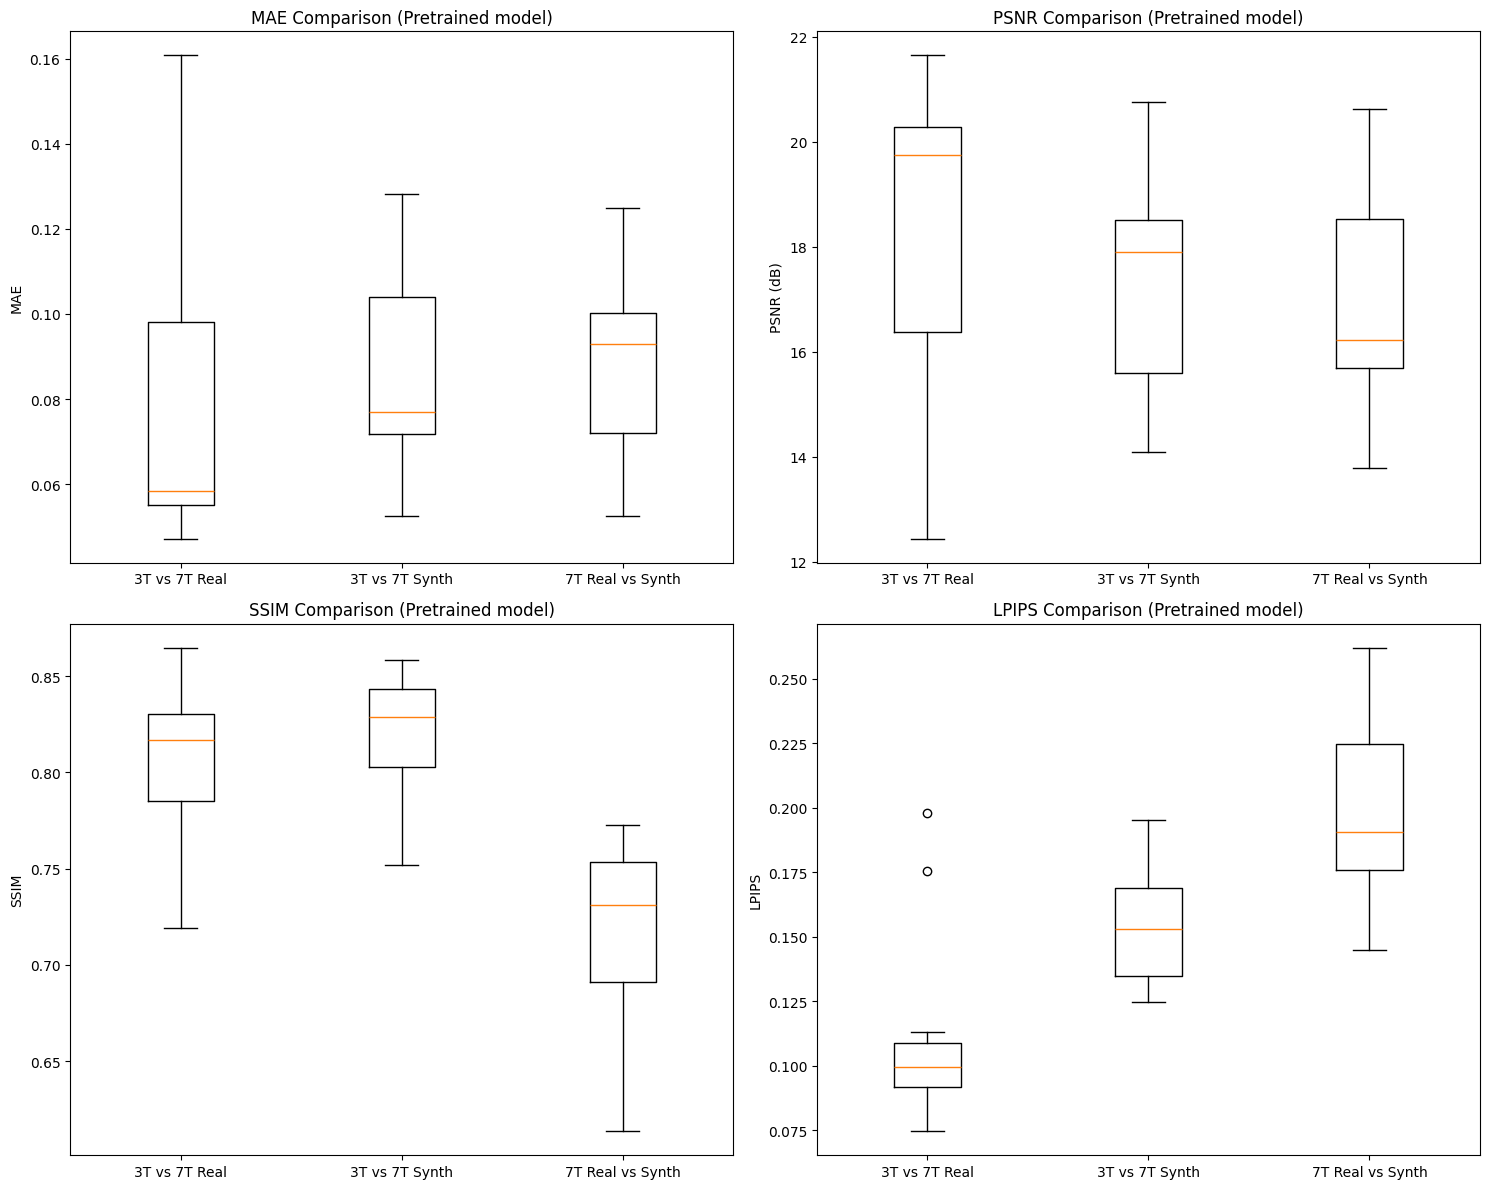

sub-MS3T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T009_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)


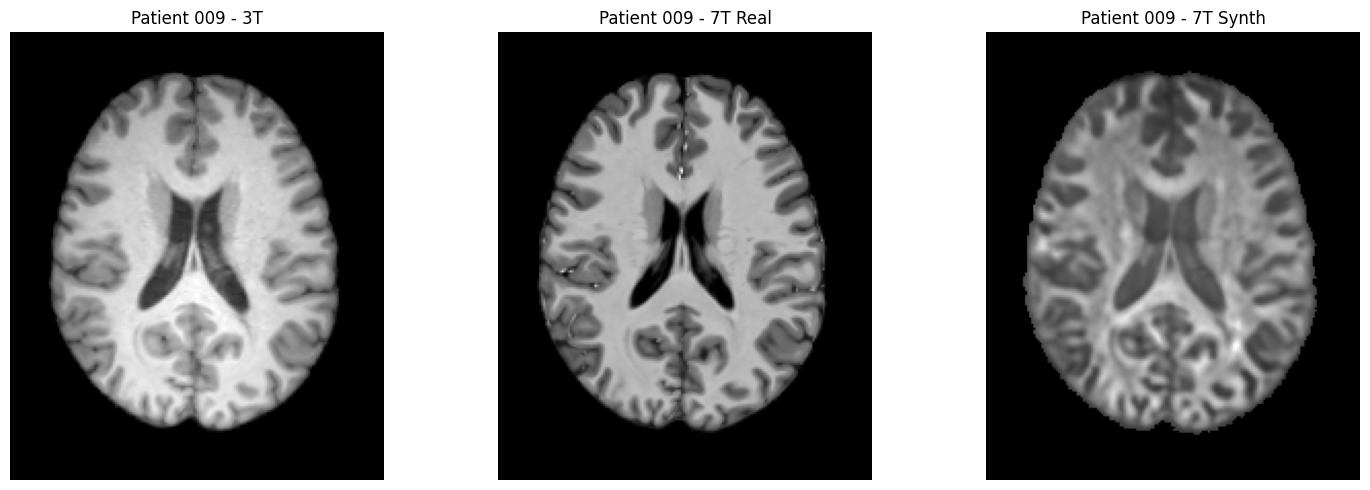

Best 7T synthesis for patient: 009


In [62]:

# Plot metrics comparison if we have results
if len(results_pretrained) > 0:
    print("\n📊 Plotting metrics comparison for pretrained model...")
    plot_metrics_comparison()

# # Usage Examples:
# 
# ```python
# # Show images for a specific patient
show_patient_images("009")
# 
# # Access the results dataframe
# print(df_results.head())
# 
# # Get best performing patient for 7T synthesis
best_patient = df_results_pretrained.loc[df_results_pretrained['mae_7T_real_synth_p'].idxmin()]
print(f"Best 7T synthesis for patient: {best_patient['patient_id']}")

## Our implemented Model 


📊 Plotting metrics comparison...


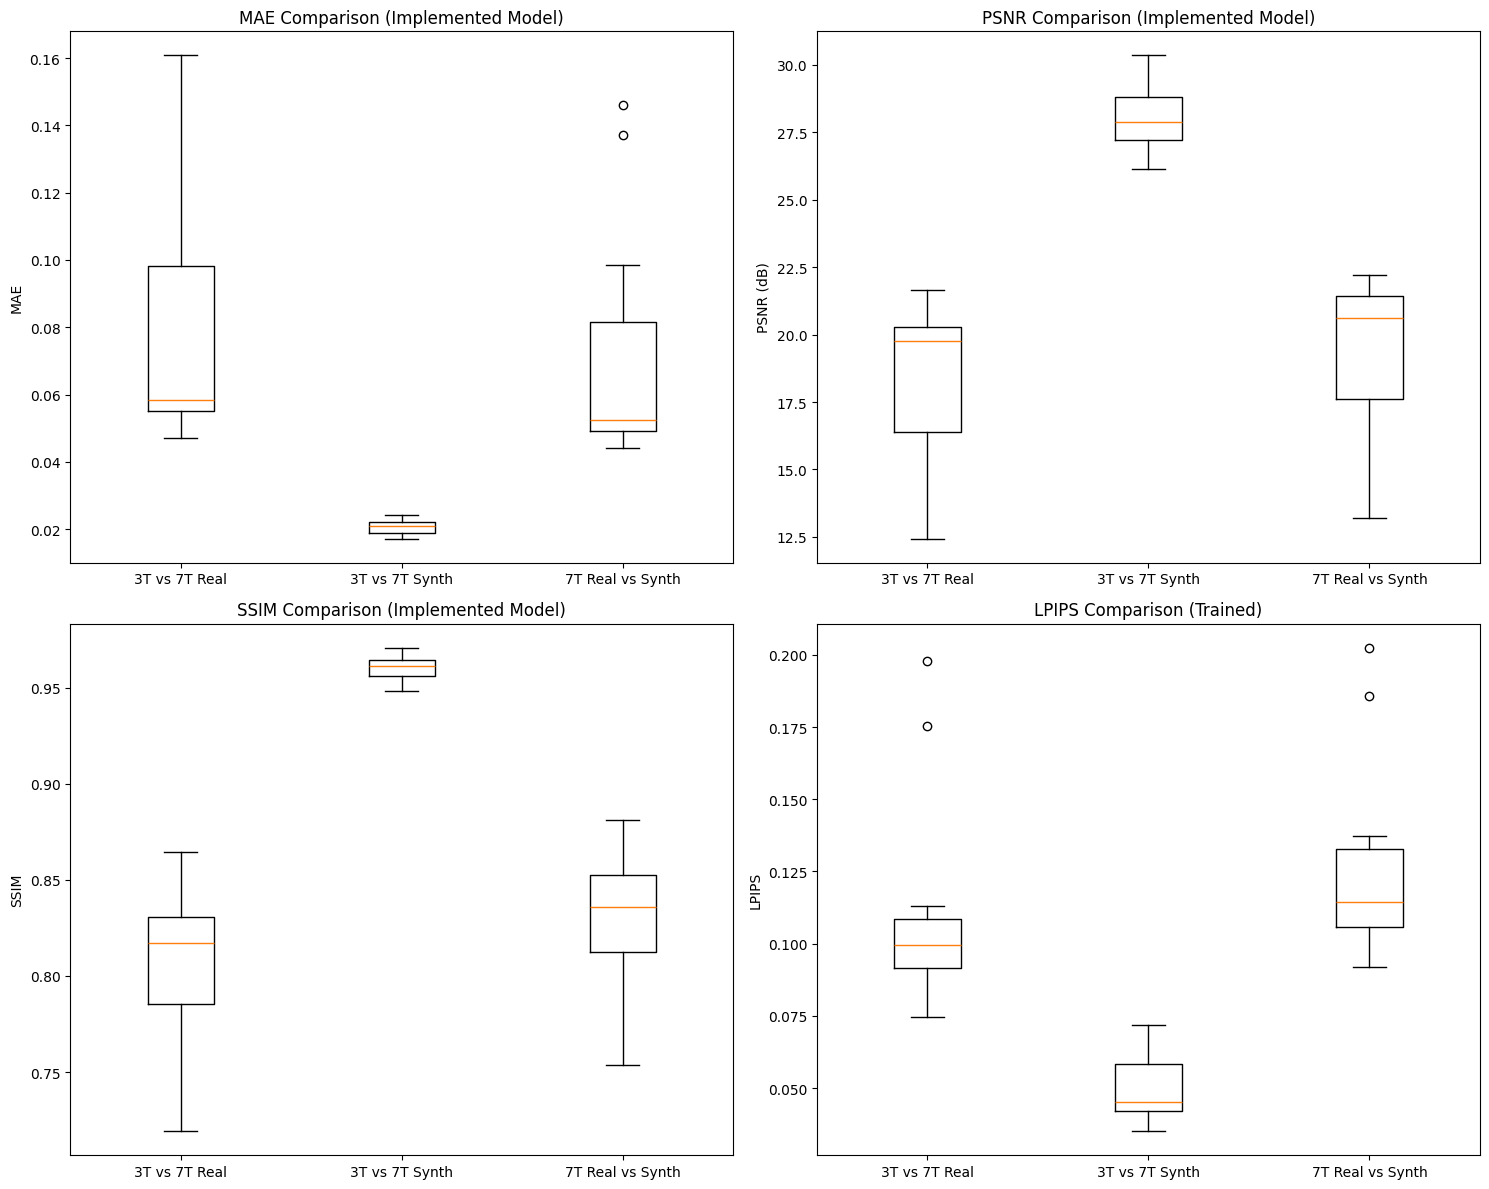

sub-MS3T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T009_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)


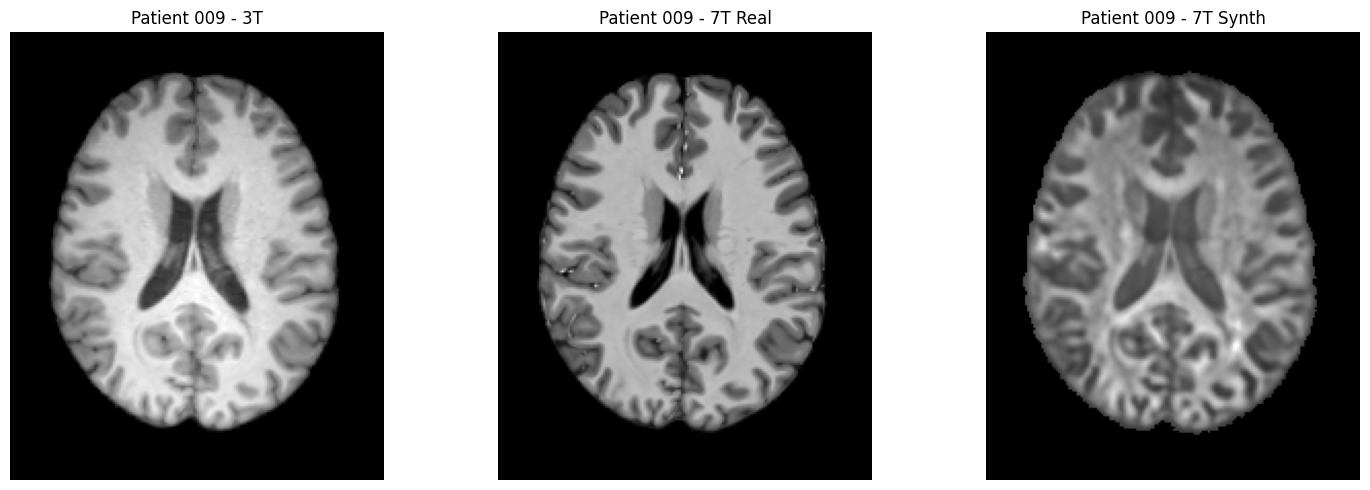

Best 7T synthesis for patient: 012


In [58]:

# Plot metrics comparison if we have results
if len(results_trained) > 0:
    print("\n📊 Plotting metrics comparison for out implemented model")
    plot_metrics_comparison_trained()

# # Usage Examples:
# 
# ```python
# # Show images for a specific patient
show_patient_images("009")
# 
# # Access the results dataframe
# print(df_results.head())
# 
# # Get best performing patient for 7T synthesis
best_patient_trained = df_results_trained.loc[df_results_trained['mae_7T_real_synth_t'].idxmin()]
print(f"Best 7T synthesis for patient: {best_patient_trained['patient_id']}")

## Implemented : Final Model


📊 Plotting metrics comparison for out implemented model


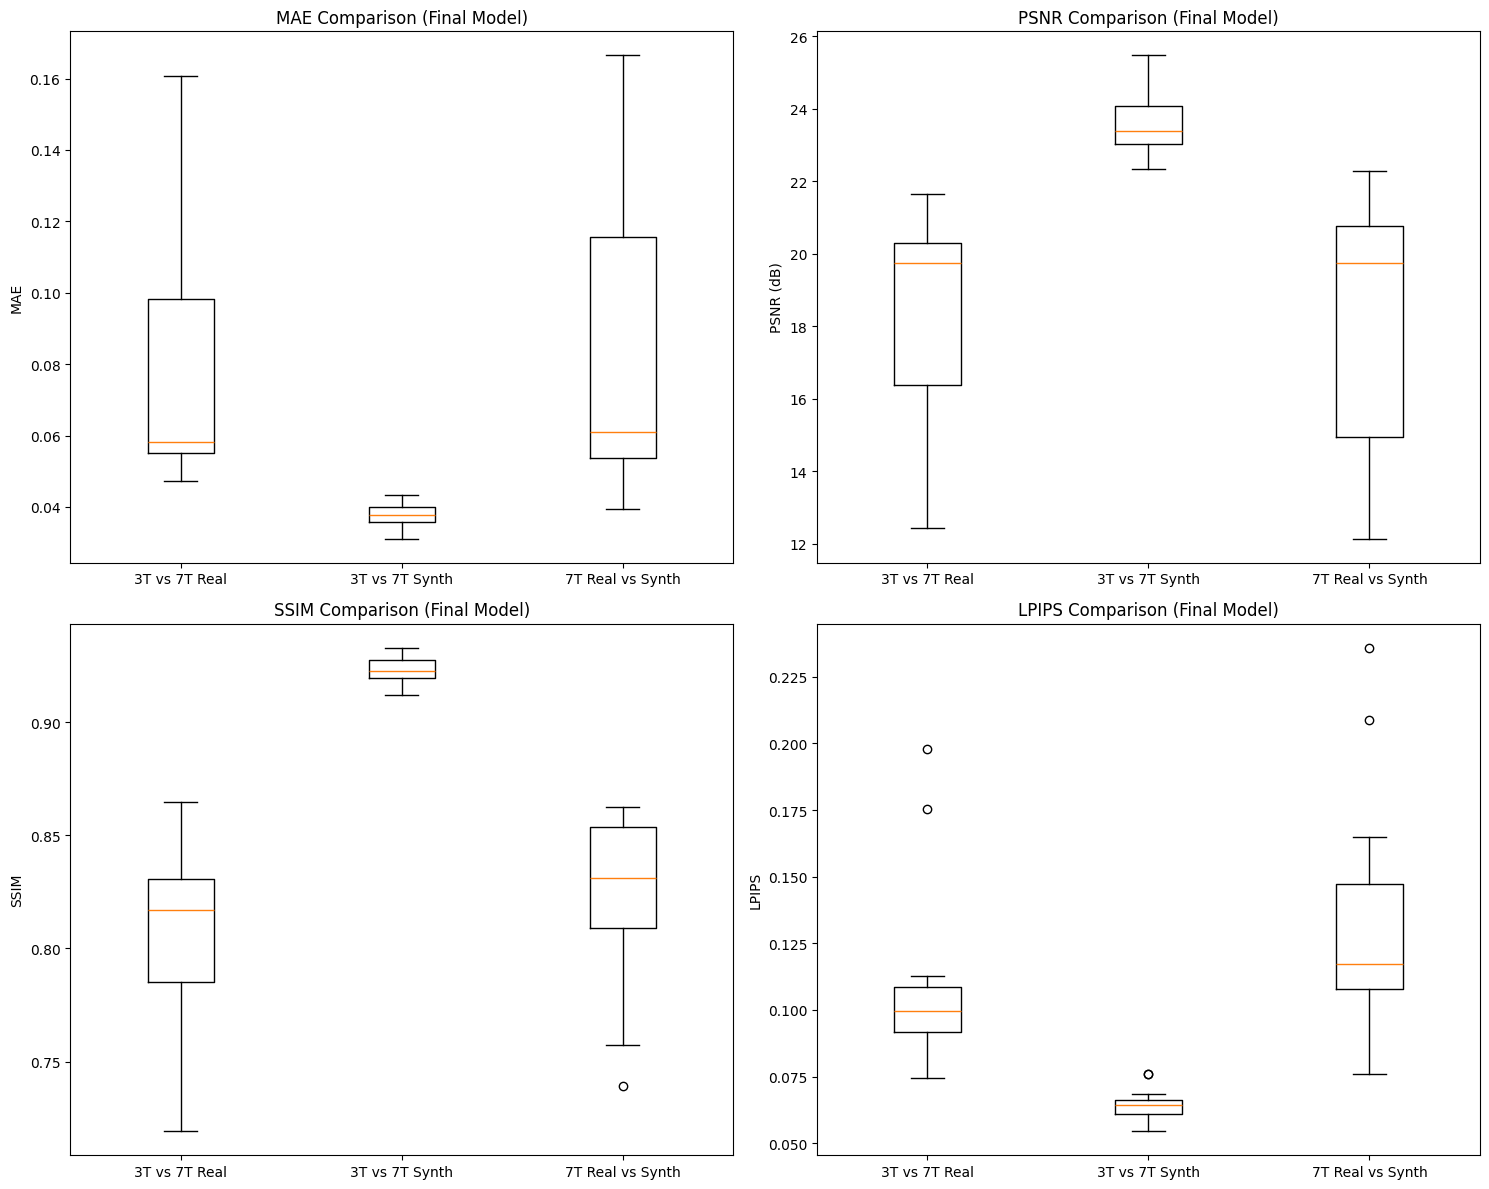

sub-MS3T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS7T009_T1w_MNI152_ANTs.nii.gz: (182, 218, 182)
sub-MS3T009_T1w_MNI152_ANTs_pred.nii.gz: (182, 218, 182)


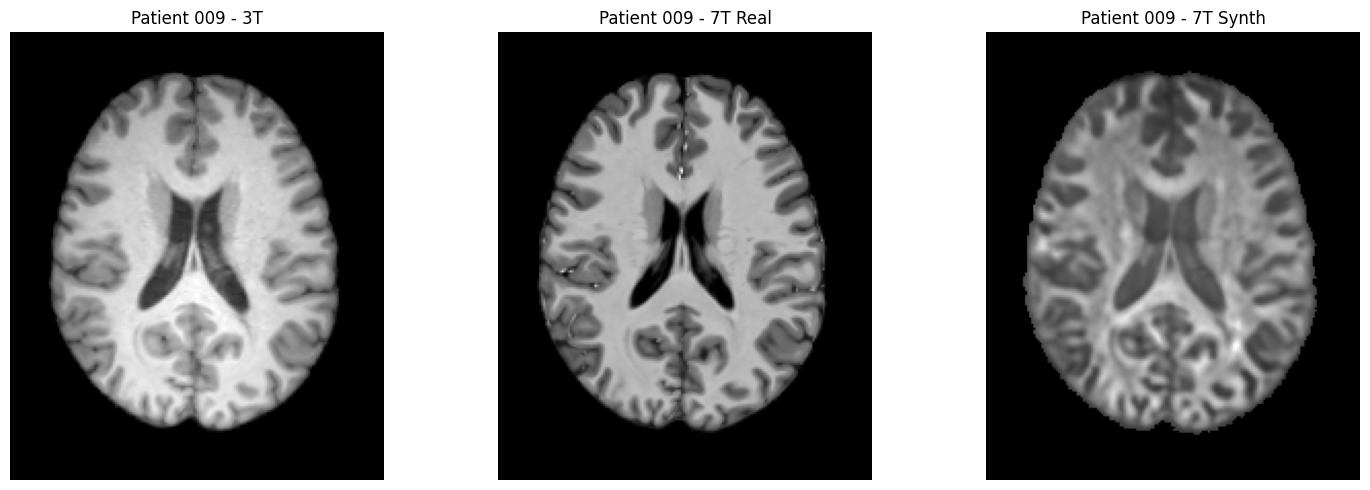

Best 7T synthesis for patient: 018


In [90]:

# Plot metrics comparison if we have results
if len(results_trained_fullepochs) > 0:
    print("\n📊 Plotting metrics comparison for out implemented model")
    plot_metrics_comparison_trained_f()

# # Usage Examples:
# 
# ```python
# # Show images for a specific patient
show_patient_images("009")
# 
# # Access the results dataframe
# print(df_results.head())
# 
# # Get best performing patient for 7T synthesis
best_patient_trained_f = df_results_trained_f.loc[df_results_trained_f['mae_7T_real_synth_t_f'].idxmin()]
print(f"Best 7T synthesis for patient: {best_patient_trained_f['patient_id']}")

# Combined Pretrained & Implemented 


In [55]:
print(f"\n{'='*70}")
print("📊 FINAL ANALYSIS - COMBINED RESULTS")
print(f"{'='*70}")

# Check if we have results from both models
if len(results_pretrained) == 0 and len(results_trained) == 0:
    print("❌ No patients processed successfully for either model!")
elif len(results_pretrained) == 0:
    print("❌ No pretrained model results available!")
elif len(results_trained) == 0:
    print("❌ No trained model results available!")
else:
    # Convert results to separate DataFrames
    df_pretrained = pd.DataFrame(results_pretrained)
    df_trained = pd.DataFrame(results_trained)

    # Rename columns to align naming
    pretrained_suffix = '_synth_p'
    trained_suffix = '_synth_t'

    # Define key metrics
    key_metrics = [
        'mae_3T_7T_real', f'mae_3T_7T{pretrained_suffix}', f'mae_7T_real{pretrained_suffix}',
        'psnr_3T_7T_real', f'psnr_3T_7T{pretrained_suffix}', f'psnr_7T_real{pretrained_suffix}',
        'ssim_3T_7T_real', f'ssim_3T_7T{pretrained_suffix}', f'ssim_7T_real{pretrained_suffix}'
    ]
    if LPIPS_AVAILABLE and lpips_model:
        key_metrics += [
            f'lpips_3T_7T_real', f'lpips_3T_7T{pretrained_suffix}', f'lpips_7T_real{pretrained_suffix}'
        ]

    # Rename trained model metrics
    df_trained = df_trained.rename(columns={
        f'mae_3T_7T{trained_suffix}': f'mae_3T_7T{pretrained_suffix}',
        f'mae_7T_real{trained_suffix}': f'mae_7T_real{pretrained_suffix}',
        f'psnr_3T_7T{trained_suffix}': f'psnr_3T_7T{pretrained_suffix}',
        f'psnr_7T_real{trained_suffix}': f'psnr_7T_real{pretrained_suffix}',
        f'ssim_3T_7T{trained_suffix}': f'ssim_3T_7T{pretrained_suffix}',
        f'ssim_7T_real{trained_suffix}': f'ssim_7T_real{pretrained_suffix}',
        f'lpips_3T_7T{trained_suffix}': f'lpips_3T_7T{pretrained_suffix}' if LPIPS_AVAILABLE else None,
        f'lpips_7T_real{trained_suffix}': f'lpips_7T_real{pretrained_suffix}' if LPIPS_AVAILABLE else None,
    })

    # Add model identifiers
    df_pretrained['model_type'] = 'Pretrained'
    df_trained['model_type'] = 'Trained'

    # Combine both DataFrames
    df_combined = pd.concat([df_pretrained, df_trained], ignore_index=True)

    # Save individual and combined results
    OUTPUT_CSV_PRETRAINED = "pretrained_model_results.csv"
    OUTPUT_CSV_TRAINED = "trained_model_results.csv"
    OUTPUT_CSV_COMBINED = "combined_model_results.csv"

    df_pretrained.to_csv(OUTPUT_CSV_PRETRAINED, index=False)
    df_trained.to_csv(OUTPUT_CSV_TRAINED, index=False)
    df_combined.to_csv(OUTPUT_CSV_COMBINED, index=False)

    print(f"💾 Pretrained results saved to: {OUTPUT_CSV_PRETRAINED}")
    print(f"💾 Trained results saved to: {OUTPUT_CSV_TRAINED}")
    print(f"💾 Combined results saved to: {OUTPUT_CSV_COMBINED}")
    print(f"✓ Successfully processed {len(df_pretrained)} patients (Pretrained) and {len(df_trained)} patients (Trained)")

    print(f"\n📈 COMPARATIVE SUMMARY STATISTICS")
    print("="*70)

    for metric in key_metrics:
        print(f"\n🔍 {metric.upper()}:")
        print("-" * 50)

        if metric not in df_pretrained or metric not in df_trained:
            print(f"⚠️ Skipped {metric}: missing in one of the DataFrames.")
            continue

        pretrained_stats = df_pretrained[metric].describe()
        trained_stats = df_trained[metric].describe()

        comparison_df = pd.DataFrame({
            'Pretrained': pretrained_stats,
            'Trained': trained_stats
        })
        print(comparison_df.round(4))

        pretrained_mean = df_pretrained[metric].mean()
        trained_mean = df_trained[metric].mean()

        if 'mae' in metric.lower() or 'lpips' in metric.lower():
            improvement = ((pretrained_mean - trained_mean) / pretrained_mean) * 100
            direction = "↓ Reduction" if improvement > 0 else "↑ Increase"
        else:
            improvement = ((trained_mean - pretrained_mean) / pretrained_mean) * 100
            direction = "↑ Improvement" if improvement > 0 else "↓ Degradation"

        print(f"   📊 {direction}: {abs(improvement):.2f}%")

    # SIDE-BY-SIDE COMPARISON
    print(f"\n📋 SIDE-BY-SIDE COMPARISON (First 5 Patients):")
    print("="*70)

    common_patients = set(df_pretrained['patient_id']) & set(df_trained['patient_id'])

    if len(common_patients) == 0:
        print("⚠️ No common patient IDs found between pretrained and trained results!")
    else:
        comparison_table = []
        for patient_id in list(common_patients)[:5]:
            pre_row = df_pretrained[df_pretrained['patient_id'] == patient_id].iloc[0]
            tr_row = df_trained[df_trained['patient_id'] == patient_id].iloc[0]

            row_data = {'patient_id': patient_id}
            for metric in key_metrics:
                if metric not in pre_row or metric not in tr_row:
                    continue
                pre_val = pre_row[metric]
                tr_val = tr_row[metric]
                row_data[f'{metric}_pretrained'] = pre_val
                row_data[f'{metric}_trained'] = tr_val
                row_data[f'{metric}_diff'] = tr_val - pre_val
                row_data[f'{metric}_improvement'] = (
                    ((pre_val - tr_val) / pre_val * 100)
                    if 'mae' in metric.lower() or 'lpips' in metric.lower()
                    else ((tr_val - pre_val) / pre_val * 100)
                )
            comparison_table.append(row_data)

        df_comparison = pd.DataFrame(comparison_table)

        display_metrics = ['mae_3T_7T_real', 'psnr_3T_7T_real', 'ssim_3T_7T_real']
        for metric in display_metrics:
            print(f"\n📊 {metric.upper()} Comparison:")
            cols = ['patient_id', f'{metric}_pretrained', f'{metric}_trained', f'{metric}_diff', f'{metric}_improvement']
            print(df_comparison[cols].round(4).rename(columns={
                f'{metric}_pretrained': 'Pretrained',
                f'{metric}_trained': 'Trained',
                f'{metric}_diff': 'Difference',
                f'{metric}_improvement': 'Improvement_%',
                'patient_id': 'Patient_ID'
            }))

    print(f"\n🏆 OVERALL PERFORMANCE SUMMARY:")
    print("="*70)

    improvements = {}
    for metric in key_metrics:
        if metric in df_pretrained and metric in df_trained:
            mean_pre = df_pretrained[metric].mean()
            mean_tr = df_trained[metric].mean()
            if 'mae' in metric.lower() or 'lpips' in metric.lower():
                imp = ((mean_pre - mean_tr) / mean_pre) * 100
            else:
                imp = ((mean_tr - mean_pre) / mean_pre) * 100
            improvements[metric] = imp

    sorted_improvements = sorted(improvements.items(), key=lambda x: abs(x[1]), reverse=True)

    print("📈 Top 5 Metric Improvements/Changes:")
    for i, (metric, imp) in enumerate(sorted_improvements[:5], 1):
        status = "✅ Improved" if imp > 0 else "❌ Degraded"
        print(f"   {i}. {metric}: {status} by {abs(imp):.2f}%")

    # Paired t-test (only if multiple common patients)
    if len(common_patients) > 1:
        print(f"\n📊 STATISTICAL TESTS (Paired t-test on {len(common_patients)} common patients):")
        print("-" * 50)
        from scipy import stats
        for metric in key_metrics[:3]:
            pretrained_vals = []
            trained_vals = []
            for pid in common_patients:
                try:
                    val_pre = df_pretrained[df_pretrained['patient_id'] == pid][metric].iloc[0]
                    val_tr = df_trained[df_trained['patient_id'] == pid][metric].iloc[0]
                    pretrained_vals.append(val_pre)
                    trained_vals.append(val_tr)
                except:
                    continue
            if pretrained_vals and trained_vals:
                t_stat, p_value = stats.ttest_rel(pretrained_vals, trained_vals)
                sig = "Significant" if p_value < 0.05 else "Not Significant"
                print(f"   {metric}: t={t_stat:.4f}, p={p_value:.4f} ({sig})")
    else:
        print(f"\n⚠️  Cannot perform paired t-test: only {len(common_patients)} common patient(s)")

    print(f"\n✅ Analysis complete! Check the CSV files for detailed results:")
    print(f"   - {OUTPUT_CSV_PRETRAINED}")
    print(f"   - {OUTPUT_CSV_TRAINED}")
    print(f"   - {OUTPUT_CSV_COMBINED}")



📊 FINAL ANALYSIS - COMBINED RESULTS
💾 Pretrained results saved to: pretrained_model_results.csv
💾 Trained results saved to: trained_model_results.csv
💾 Combined results saved to: combined_model_results.csv
✓ Successfully processed 18 patients (Pretrained) and 18 patients (Trained)

📈 COMPARATIVE SUMMARY STATISTICS

🔍 MAE_3T_7T_REAL:
--------------------------------------------------
       Pretrained  Trained
count     18.0000  18.0000
mean       0.0762   0.0762
std        0.0341   0.0341
min        0.0472   0.0472
25%        0.0552   0.0552
50%        0.0583   0.0583
75%        0.0982   0.0982
max        0.1608   0.1608
   📊 ↑ Increase: 0.00%

🔍 MAE_3T_7T_SYNTH_P:
--------------------------------------------------
       Pretrained  Trained
count     18.0000  18.0000
mean       0.0857   0.0206
std        0.0231   0.0023
min        0.0526   0.0172
25%        0.0717   0.0188
50%        0.0769   0.0208
75%        0.1041   0.0222
max        0.1282   0.0241
   📊 ↓ Reduction: 75.96%

🔍 MAE